# GHIST+ BreastCancer2 Inference

This notebook runs GHIST+ BreastCancer2 fullslide inference using only the H&E image, nuclei segmentation, saved checkpoint, and a compact train-derived reference.


## Figure 2

In [ ]:
from pathlib import Path
import importlib.util
import os
import shutil
import sys

import numpy as np
import pandas as pd
import torch

REPO = Path(os.environ.get("REPO_DIR", Path.cwd())).expanduser().resolve()
if not (REPO / "tools" / "inference.py").exists():
    raise FileNotFoundError("Run this notebook from the repository root or set REPO_DIR.")
BUNDLE = Path(os.environ.get("EXAMPLE_BUNDLE", REPO.parent / "example_bundle")).expanduser().resolve()

CONFIG = REPO / "configs" / "config_breast2_inference_example.json"
INFERENCE_PY = REPO / "tools" / "inference.py"
ARTIFACTS = BUNDLE / "model_artifacts" / "breast"
CHECKPOINT = ARTIFACTS / "best_model" / "best_model.pth"
IMPUTE_DIR = ARTIFACTS / "imputed_33f50e3f_fixedsvg10"
AVGEXP_REF = ARTIFACTS / "avgexp_ref_slide_specific_train_derived.npz"
CACHE_DIR = ARTIFACTS / "cache"
OUTPUT_DIR = BUNDLE / "inference_outputs" / "breast2_fullslide"

os.environ["DATA_ROOT"] = str(BUNDLE / "example_data")
os.environ["RUN_ROOT"] = str(BUNDLE / "model_artifacts")
os.environ["CACHE_ROOT"] = str(ARTIFACTS)

required = [
    CONFIG,
    INFERENCE_PY,
    CHECKPOINT,
    ARTIFACTS / "genes.txt",
    ARTIFACTS / "standardisation_hist_fold_1.npy",
    AVGEXP_REF,
    IMPUTE_DIR / "test_slide3_domain0_mask.npy",
    BUNDLE / "example_data" / "breast" / "aligned_he_image.tif",
    BUNDLE / "example_data" / "data_processing" / "data_processing_breast2" / "he_image.tif",
    BUNDLE / "example_data" / "data_processing" / "data_processing_breast2" / "he_image_nuclei_seg.tif",
    BUNDLE / "example_data" / "data_processing" / "data_processing_breast2" / "matched_nuclei_filtered.csv",
    BUNDLE / "example_data" / "data_processing" / "data_processing_breast2" / "cell_coords.csv",
]
cache_files = sorted(CACHE_DIR.glob("dataset_*.pt"))
missing = [str(p) for p in required if not p.exists()]
if missing:
    raise FileNotFoundError("Missing required files:\n" + "\n".join(missing))
if not cache_files:
    raise FileNotFoundError(f"Missing stripped no-target cache in {CACHE_DIR}")

print("Repo:", REPO)
print("Bundle:", BUNDLE)
print("Output:", OUTPUT_DIR)
print("Bundled cache:", cache_files[0])


In [ ]:
def load_module(path, name):
    spec = importlib.util.spec_from_file_location(name, str(path))
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    return module


def ensure_no_target_cache(trainer):
    from dataio.dataset_input import _build_cache_path
    from utils.utils import json_file_to_pyobj, read_txt

    opts = trainer._to_namespace(json_file_to_pyobj(str(CONFIG)))
    source = next(s for s in opts.data_sources_test if int(s.slide_idx) == 3)
    gene_names = read_txt(str(ARTIFACTS / "genes.txt"))
    fold_id = 1
    divisions_fold = opts.regions_test.divisions[fold_id - 1]
    meta = {
        "fp_hist": source.fp_hist,
        "fp_nuc_seg": source.fp_nuc_seg,
        "fp_expr": None,
        "fp_cell_type": None,
        "fp_nuc_sizes": source.fp_nuc_sizes,
        "mode": "test",
        "fold_id": fold_id,
        "hsize": int(opts.data.hsize),
        "wsize": int(opts.data.wsize),
        "overlap": int(opts.data.overlap),
        "divisions": divisions_fold,
        "gene_names": gene_names,
        "hist_mtime": os.path.getmtime(source.fp_hist),
        "nuc_mtime": os.path.getmtime(source.fp_nuc_seg),
        "expr_mtime": None,
        "celltype_mtime": None,
        "nuc_sizes_mtime": os.path.getmtime(source.fp_nuc_sizes),
    }
    expected_cache = _build_cache_path(str(ARTIFACTS), meta)
    bundled_cache = sorted(CACHE_DIR.glob("dataset_*.pt"))[0]

    payload = torch.load(bundled_cache, map_location="cpu", weights_only=False)
    if payload.get("df_expr") is not None or payload.get("df_ct") is not None:
        raise RuntimeError("Bundled cache is not target-free: df_expr/df_ct must be None.")
    if expected_cache != bundled_cache and not expected_cache.exists():
        shutil.copy2(bundled_cache, expected_cache)
    print("No-target cache:", expected_cache)
    return expected_cache


def use_precomputed_avgexp(trainer, ref_path):
    ref = np.load(ref_path, allow_pickle=True)
    ref_slide_ids = [int(x) for x in ref["slide_ids"].tolist()]
    ref_by_slide = ref["expr_ref_by_slide"].astype(np.float32)
    ref_mean = ref["expr_ref_mean"].astype(np.float32)
    ref_genes = [str(x) for x in ref["gene_names"].tolist()]
    ref_classes = [str(x) for x in ref["classes"].tolist()]

    def build_avgexp_df_by_slide(all_sources, stats_sources, gene_names, classes, expr_scale, **kwargs):
        gene_pos = {g: i for i, g in enumerate(ref_genes)}
        class_pos = {c: i for i, c in enumerate(ref_classes)}
        missing_genes = [g for g in gene_names if g not in gene_pos]
        missing_classes = [c for c in classes if c not in class_pos]
        if missing_genes or missing_classes:
            raise ValueError(
                f"Avgexp reference mismatch: missing_genes={len(missing_genes)} "
                f"missing_classes={len(missing_classes)}"
            )

        gene_idx = [gene_pos[g] for g in gene_names]
        class_idx = [class_pos[c] for c in classes]
        mean_df = pd.DataFrame(ref_mean[np.ix_(class_idx, gene_idx)], index=classes, columns=gene_names)
        slide_df = {
            sid: pd.DataFrame(ref_by_slide[i][np.ix_(class_idx, gene_idx)], index=classes, columns=gene_names)
            for i, sid in enumerate(ref_slide_ids)
        }
        return {
            int(getattr(src, "slide_idx", -1)): slide_df.get(int(getattr(src, "slide_idx", -1)), mean_df)
            for src in all_sources
        }

    trainer.reference_utils.build_avgexp_df_by_slide = build_avgexp_df_by_slide
    trainer.build_avgexp_df_by_slide = build_avgexp_df_by_slide
    return trainer


inference = load_module(INFERENCE_PY, "inference_module")
trainer = inference._load_nature_trainer(REPO)
trainer = use_precomputed_avgexp(trainer, AVGEXP_REF)
ensure_no_target_cache(trainer)
inference._load_nature_trainer = lambda nature_root: trainer

print("Using avgexp reference:", AVGEXP_REF)


In [ ]:
GPU_ID = 0
BATCH_SIZE = 64
NUM_WORKERS = 32
LOG_EVERY = 10

argv = [
    "tools/inference.py",
    "--nature_root", str(REPO),
    "--experiment_path", str(ARTIFACTS),
    "--config_file", str(CONFIG),
    "--checkpoint_path", str(CHECKPOINT),
    "--impute_dir", str(IMPUTE_DIR),
    "--fold_id", "1",
    "--slide_id", "3",
    "--gpu_id", str(GPU_ID),
    "--num_workers", str(NUM_WORKERS),
    "--batch_size", str(BATCH_SIZE),
    "--output_dir", str(OUTPUT_DIR),
    "--log_every", str(LOG_EVERY),
    "--skip_metrics",
]

old_argv = sys.argv
try:
    sys.argv = argv
    inference.main()
finally:
    sys.argv = old_argv


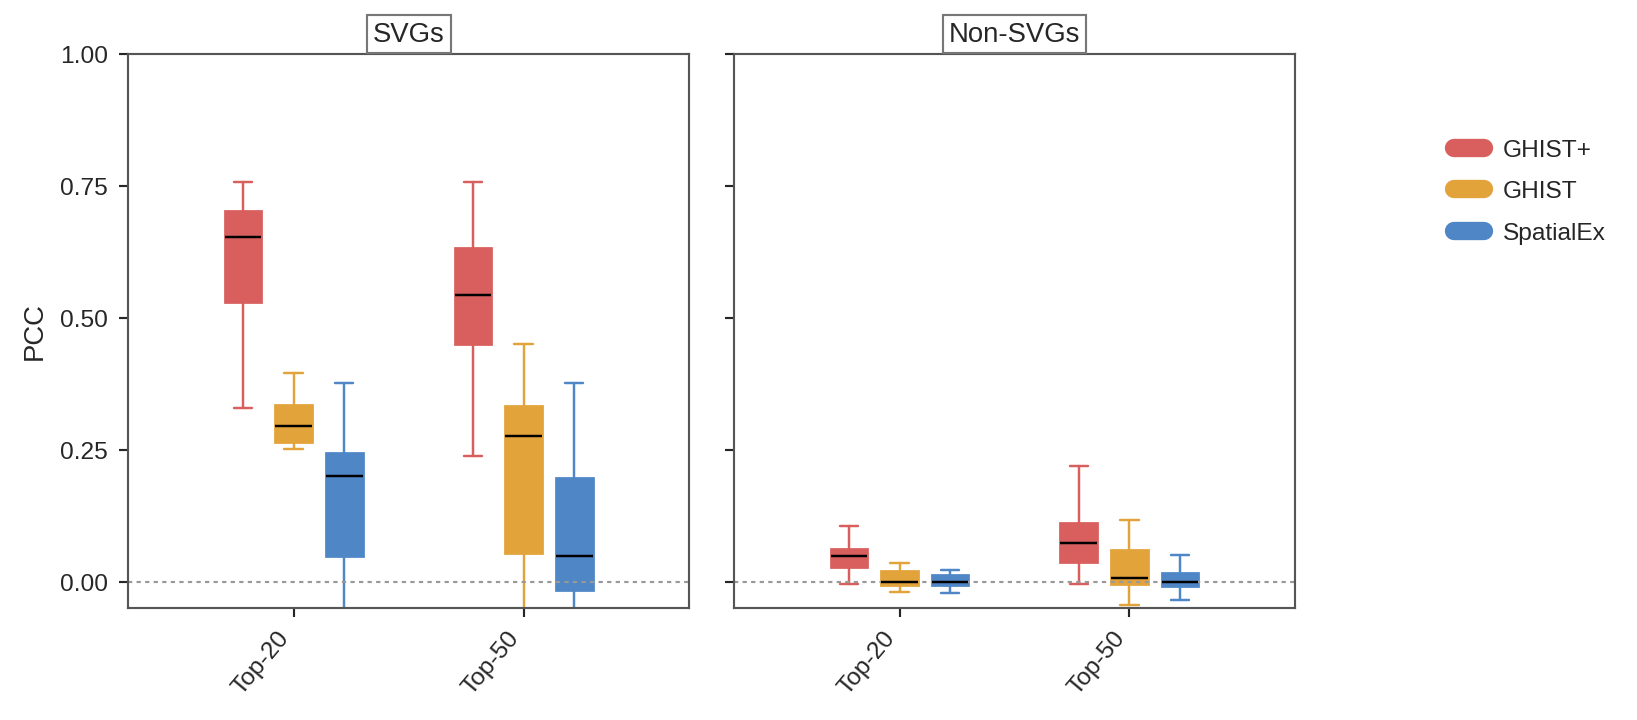

In [20]:
import json
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from scipy.stats import rankdata

REPO = Path(globals().get("REPO", Path.cwd()))
BUNDLE = Path(globals().get("BUNDLE", REPO.parent / "example_bundle"))
CONFIG = Path(globals().get("CONFIG", REPO / "configs" / "config_breast2_inference_example.json"))
OUTPUT_DIR = Path(globals().get("OUTPUT_DIR", BUNDLE / "inference_outputs" / "breast2_fullslide"))

ASSET_DIR = BUNDLE / "manuscript_assets" / "fig2_fig4_breast_checkpoint"

def latest_file(folder, pattern):
    hits = sorted(Path(folder).glob(pattern))
    return hits[-1] if hits else None

fp_ghist_plus = latest_file(OUTPUT_DIR, "*_pred_expr_scaled.csv")
fp_ghist = ASSET_DIR / "ghist" / "breast2_ghist_epoch30_pred_expr.csv"
fp_spatialex = ASSET_DIR / "spatialex" / "breast2_spatialex_pred_expr.csv"
fp_gt_counts = ASSET_DIR / "ground_truth" / "cell_gene_matrix_filtered.csv"
fp_coords = ASSET_DIR / "ground_truth" / "cell_coords.csv"

required = {
    "GHIST+ prediction": fp_ghist_plus,
    "GHIST prediction": fp_ghist,
    "SpatialEx prediction": fp_spatialex,
    "ground-truth expression": fp_gt_counts,
    "cell coordinates": fp_coords,
    "config": CONFIG,
}

missing = [name for name, path in required.items() if path is None or not Path(path).exists()]
if missing:
    raise FileNotFoundError("Missing required file(s): " + ", ".join(missing))

with open(CONFIG, "r", encoding="utf-8") as f:
    expr_scale = float(json.load(f)["data"]["expr_scale"])

def as_int_index(df):
    df = df.copy()
    try:
        df.index = df.index.astype(int)
    except Exception:
        pass
    return df

def drop_non_gene_cols(df):
    return df.drop(
        columns=[c for c in ["x", "y", "x_coord", "y_coord"] if c in df.columns],
        errors="ignore",
    )

def pearson_per_gene(gt_df, pred_df):
    gt = gt_df.to_numpy(dtype=np.float64)
    pred = pred_df.to_numpy(dtype=np.float64)
    out = np.full(gt.shape[1], np.nan)

    for j in range(gt.shape[1]):
        a = gt[:, j]
        b = pred[:, j]
        keep = np.isfinite(a) & np.isfinite(b)
        a = a[keep]
        b = b[keep]

        if len(a) < 3:
            continue

        a = a - a.mean()
        b = b - b.mean()
        denom = np.sqrt((a * a).sum() * (b * b).sum())

        if denom > 0:
            out[j] = (a * b).sum() / denom

    return pd.Series(out, index=gt_df.columns)

def giotto_rank_scores(expr, coords, k=8):
    tree = cKDTree(coords)
    neigh_idx = tree.query(coords, k=k + 1)[1][:, 1:]
    scores = np.zeros(expr.shape[1], dtype=np.float32)

    for g in range(expr.shape[1]):
        ranks = rankdata(expr[:, g], method="average").astype(np.float32)
        neigh_mean = ranks[neigh_idx].mean(axis=1)
        r_center = ranks - ranks.mean()
        n_center = neigh_mean - neigh_mean.mean()
        denom = np.sqrt((r_center ** 2).sum() * (n_center ** 2).sum())

        if denom > 0:
            scores[g] = np.dot(r_center, n_center) / denom

    return scores

df_plus = drop_non_gene_cols(as_int_index(pd.read_csv(fp_ghist_plus, index_col=0)))
df_ghist = drop_non_gene_cols(as_int_index(pd.read_csv(fp_ghist, index_col=0)))
df_spatialex_raw = drop_non_gene_cols(as_int_index(pd.read_csv(fp_spatialex, index_col=0)))
df_gt_raw = drop_non_gene_cols(as_int_index(pd.read_csv(fp_gt_counts, index_col=0)))

df_gt = expr_scale * np.log1p(df_gt_raw.clip(lower=0))
df_spatialex = expr_scale * np.log1p(df_spatialex_raw.clip(lower=0))

models = {
    "GHIST+": df_plus,
    "GHIST": df_ghist,
    "SpatialEx": df_spatialex,
}

shared_cells = sorted(set(df_gt.index).intersection(*(set(df.index) for df in models.values())))
shared_genes = sorted(set(df_gt.columns).intersection(*(set(df.columns) for df in models.values())))

df_gt = df_gt.loc[shared_cells, shared_genes]
models = {name: df.loc[shared_cells, shared_genes] for name, df in models.items()}

coords = pd.read_csv(fp_coords)
if "cell_id" in coords.columns:
    coords = coords.set_index("cell_id")
coords = as_int_index(coords).loc[shared_cells, ["x_coord", "y_coord"]]

svg_scores = giotto_rank_scores(
    df_gt.to_numpy(dtype=np.float32),
    coords.to_numpy(dtype=np.float32),
    k=8,
)

genes = np.array(shared_genes)
svg_desc_idx = np.argsort(-svg_scores, kind="stable")
non_svg_idx = np.argsort(np.abs(svg_scores), kind="stable")

model_order = ["GHIST+", "GHIST", "SpatialEx"]
model_pcc = {
    name: pearson_per_gene(df_gt, pred)
    for name, pred in models.items()
}

plot_groups = {
    "SVGs": {
        "Top-20": genes[svg_desc_idx[:20]].tolist(),
        "Top-50": genes[svg_desc_idx[:50]].tolist(),
    },
    "Non-SVGs": {
        "Top-20": genes[non_svg_idx[:20]].tolist(),
        "Top-50": genes[non_svg_idx[:50]].tolist(),
    },
}

colors = {
    "GHIST+": "#d95f5f",
    "GHIST": "#e3a33b",
    "SpatialEx": "#4f86c6",
}

fig, axes = plt.subplots(
    1,
    2,
    figsize=(7.8, 3.6),
    dpi=220,
    sharey=True,
    gridspec_kw={"wspace": 0.08},
)

for ax, (panel_name, subsets) in zip(axes, plot_groups.items()):
    x_centers = np.arange(len(subsets))
    offsets = np.linspace(-0.22, 0.22, len(model_order))
    width = 0.16

    for i, (subset_name, subset_genes) in enumerate(subsets.items()):
        for offset, model_name in zip(offsets, model_order):
            vals = model_pcc[model_name].loc[subset_genes].dropna().to_numpy(float)

            ax.boxplot(
                vals,
                positions=[x_centers[i] + offset],
                widths=width,
                patch_artist=True,
                showfliers=False,
                boxprops=dict(
                    facecolor=colors[model_name],
                    edgecolor=colors[model_name],
                    linewidth=0.9,
                ),
                medianprops=dict(color="black", linewidth=0.8),
                whiskerprops=dict(color=colors[model_name], linewidth=0.8),
                capprops=dict(color=colors[model_name], linewidth=0.8),
            )

    ax.set_title(
        panel_name,
        fontsize=9,
        pad=4,
        bbox=dict(
            facecolor="white",
            edgecolor="#777777",
            linewidth=0.7,
            boxstyle="square,pad=0.22",
        ),
    )
    ax.set_xticks(x_centers)
    ax.set_xticklabels(list(subsets.keys()), rotation=50, ha="right", fontsize=8)
    ax.axhline(0, color="#999999", linewidth=0.7, linestyle=(0, (2, 2)))
    ax.set_ylim(-0.05, 1.0)
    ax.set_yticks([0.0, 0.25, 0.5, 0.75, 1.0])
    ax.grid(False)
    ax.tick_params(axis="y", labelsize=8, width=0.7, length=3)
    ax.tick_params(axis="x", width=0.7, length=3, pad=3)

    for spine in ax.spines.values():
        spine.set_linewidth(0.7)
        spine.set_color("#555555")

axes[0].set_ylabel("PCC", fontsize=9)
axes[1].tick_params(labelleft=False)

handles = [
    plt.Line2D([0], [0], color=colors[m], lw=6, label=m, solid_capstyle="round")
    for m in model_order
]

fig.legend(
    handles=handles,
    loc="upper left",
    bbox_to_anchor=(0.84, 0.82),
    bbox_transform=fig.transFigure,
    frameon=False,
    fontsize=8,
    handlelength=1.2,
    labelspacing=0.8,
)

fig.subplots_adjust(left=0.08, right=0.76, bottom=0.2, top=0.9, wspace=0.08)
plt.show()

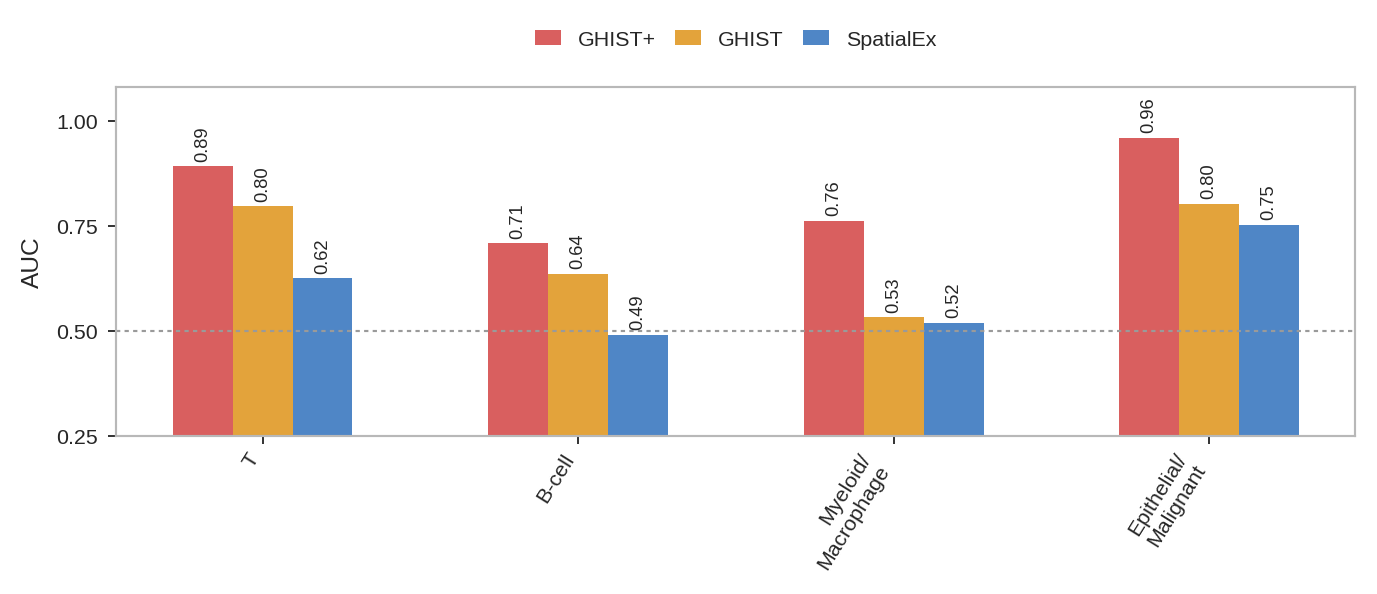

In [22]:
import json
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO = Path(globals().get("REPO", Path.cwd()))
BUNDLE = Path(globals().get("BUNDLE", REPO.parent / "example_bundle"))
CONFIG = Path(globals().get("CONFIG", REPO / "configs" / "config_breast2_inference_example.json"))
OUTPUT_DIR = Path(globals().get("OUTPUT_DIR", BUNDLE / "inference_outputs" / "breast2_fullslide"))

ASSET_DIR = BUNDLE / "manuscript_assets" / "fig2_fig4_breast_checkpoint"
GROUND_TRUTH_DIR = ASSET_DIR / "ground_truth"

def latest_file(folder, pattern):
    hits = sorted(Path(folder).glob(pattern))
    return hits[-1] if hits else None

fp_ghist_plus = latest_file(OUTPUT_DIR, "*_pred_expr_scaled.csv")
fp_ghist = ASSET_DIR / "ghist" / "breast2_ghist_epoch30_pred_expr.csv"
fp_spatialex = ASSET_DIR / "spatialex" / "breast2_spatialex_pred_expr.csv"
fp_gt_celltype = GROUND_TRUTH_DIR / "cell_type_filtered.csv"

required = {
    "GHIST+ prediction": fp_ghist_plus,
    "GHIST prediction": fp_ghist,
    "SpatialEx prediction": fp_spatialex,
    "ground-truth cell types": fp_gt_celltype,
    "config": CONFIG,
}

missing = [name for name, path in required.items() if path is None or not Path(path).exists()]
if missing:
    raise FileNotFoundError("Missing required file(s): " + ", ".join(missing))

with open(CONFIG, "r", encoding="utf-8") as f:
    expr_scale = float(json.load(f)["data"]["expr_scale"])

SOURCE_COLORS = {
    "GHIST+": "#d95f5f",
    "GHIST": "#e3a33b",
    "SpatialEx": "#4f86c6",
}

MARKER_SETS = {
    "T": {
        "positive_ct": ["T"],
        "genes": ["CD3D", "CD3E", "TRAC", "IL7R", "LTB"],
    },
    "B-cell": {
        "positive_ct": ["B"],
        "genes": ["MS4A1", "CD79A", "CD79B", "CD74", "BANK1"],
    },
    "Myeloid/\nMacrophage": {
        "positive_ct": ["Macrophage", "Myeloid (excluding macrophage)", "Myeloid"],
        "genes": ["LYZ", "ITGAX", "FCER1A", "FCER1G", "C1QA", "CST3"],
    },
    "Stromal": {
        "positive_ct": ["Stromal"],
        "genes": ["COL1A1", "COL1A2", "DCN", "TAGLN", "ACTA2", "THY1"],
    },
    "Epithelial/\nMalignant": {
        "positive_ct": ["Epithelial", "Malignant"],
        "genes": ["EPCAM", "KRT8", "KRT18", "KRT19", "MUC1", "ERBB2"],
    },
}

MIN_GENES_PER_SET = 2

def pick_col(columns, candidates):
    for c in candidates:
        if c in columns:
            return c
    return None

def load_expr_matrix(path):
    preview = pd.read_csv(path, nrows=5)
    id_col = pick_col(preview.columns, ["c_id", "cell_id", "cellID", "id"])

    if id_col is not None:
        df = pd.read_csv(path)
        df[id_col] = df[id_col].astype(str).str.strip()
        df = df.set_index(id_col)
    else:
        df = pd.read_csv(path, index_col=0)
        df.index = df.index.astype(str).str.strip()

    df.columns = df.columns.astype(str).str.strip()
    df = df.loc[~df.index.duplicated()].copy()
    df = df.loc[:, ~df.columns.duplicated()].copy()
    df = df.drop(columns=[c for c in ["x", "y", "x_coord", "y_coord"] if c in df.columns], errors="ignore")
    df = df.apply(pd.to_numeric, errors="coerce")
    return df

def load_labels(path):
    df = pd.read_csv(path, dtype=str)
    id_col = pick_col(df.columns, ["c_id", "cell_id", "cellID", "id"])
    ct_col = pick_col(df.columns, ["ct", "cell_type", "celltype", "label"])

    if id_col is None or ct_col is None:
        raise ValueError("Cell-type file must contain a cell ID column and a cell-type column.")

    df = df.rename(columns={id_col: "c_id", ct_col: "ct"})[["c_id", "ct"]].copy()
    df["c_id"] = df["c_id"].astype(str).str.strip()
    df["ct"] = df["ct"].astype(str).str.strip()
    return df.dropna(subset=["c_id", "ct"]).drop_duplicates("c_id").set_index("c_id")["ct"]

def binary_auc(y_true, scores):
    y_true = np.asarray(y_true, dtype=int)
    scores = np.asarray(scores, dtype=float)

    valid = np.isfinite(scores)
    y_true = y_true[valid]
    scores = scores[valid]

    n_pos = int(y_true.sum())
    n_neg = int((1 - y_true).sum())
    if n_pos == 0 or n_neg == 0:
        return np.nan

    ranks = pd.Series(scores).rank(method="average").to_numpy()
    sum_pos = ranks[y_true == 1].sum()
    return float((sum_pos - n_pos * (n_pos + 1) / 2.0) / (n_pos * n_neg))

def marker_auc(scores, labels, positive_classes):
    aligned_labels = labels.loc[scores.index]
    y = aligned_labels.isin(positive_classes).astype(int)
    return binary_auc(y, scores)

gt_labels = load_labels(fp_gt_celltype)

expr_sources = {
    "GHIST+": load_expr_matrix(fp_ghist_plus),
    "GHIST": load_expr_matrix(fp_ghist),
    "SpatialEx": expr_scale * np.log1p(load_expr_matrix(fp_spatialex).clip(lower=0)),
}

source_order = ["GHIST+", "GHIST", "SpatialEx"]

common_ids = set(gt_labels.index)
for src in source_order:
    common_ids &= set(expr_sources[src].index)
common_ids = sorted(common_ids)

gt_labels = gt_labels.loc[common_ids]
for src in source_order:
    expr_sources[src] = expr_sources[src].loc[common_ids]

common_genes = set(expr_sources[source_order[0]].columns)
for src in source_order[1:]:
    common_genes &= set(expr_sources[src].columns)
common_genes = sorted(common_genes)

rank_sources = {
    src: expr_sources[src][common_genes].rank(axis=0, method="average", pct=True)
    for src in source_order
}

usable_sets = []
for set_name, spec in MARKER_SETS.items():
    used_genes = [g for g in spec["genes"] if g in common_genes]
    if len(used_genes) >= MIN_GENES_PER_SET:
        usable_sets.append(set_name)

rows = []
for set_name in usable_sets:
    spec = MARKER_SETS[set_name]
    used_genes = [g for g in spec["genes"] if g in common_genes]

    for src in source_order:
        score = rank_sources[src][used_genes].mean(axis=1)
        auc = marker_auc(score, gt_labels, spec["positive_ct"])
        rows.append({
            "Marker set": set_name,
            "Source": src,
            "AUC": auc,
            "n_genes": len(used_genes),
        })

res_df = pd.DataFrame(rows)
auc_table = res_df.pivot(index="Marker set", columns="Source", values="AUC").loc[usable_sets, source_order]

fig, ax = plt.subplots(figsize=(6.4, 3.6), dpi=220, facecolor="white")

x = np.arange(len(usable_sets))
width = 0.19
offsets = np.linspace(-width, width, len(source_order))

for off, src in zip(offsets, source_order):
    vals = auc_table[src].to_numpy(dtype=float)
    bars = ax.bar(
        x + off,
        vals,
        width=width,
        color=SOURCE_COLORS[src],
        edgecolor="none",
        linewidth=0,
        label=src,
    )

    for bar, val in zip(bars, vals):
        if np.isfinite(val):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                val + 0.012,
                f"{val:.2f}",
                ha="center",
                va="bottom",
                fontsize=6.0,
                rotation=90,
            )

ax.axhline(0.5, color="#9a9a9a", linewidth=0.7, linestyle=(0, (2, 2)))
ax.set_xticks(x)
ax.set_xticklabels(usable_sets, rotation=58, ha="right", fontsize=7)
ax.set_ylabel("AUC", fontsize=8)
ax.set_ylim(0.25, 1.08)
ax.set_yticks([0.25, 0.50, 0.75, 1.00])
ax.tick_params(axis="y", labelsize=7, width=0.6, length=2.5)
ax.tick_params(axis="x", width=0.6, length=2.5, pad=2)
ax.grid(False)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("#b8b8b8")
    spine.set_linewidth(0.7)

ax.legend(
    frameon=False,
    ncol=3,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.22),
    fontsize=7,
    handlelength=1.2,
    columnspacing=0.9,
)

fig.subplots_adjust(left=0.10, right=0.98, bottom=0.34, top=0.78)
plt.show()

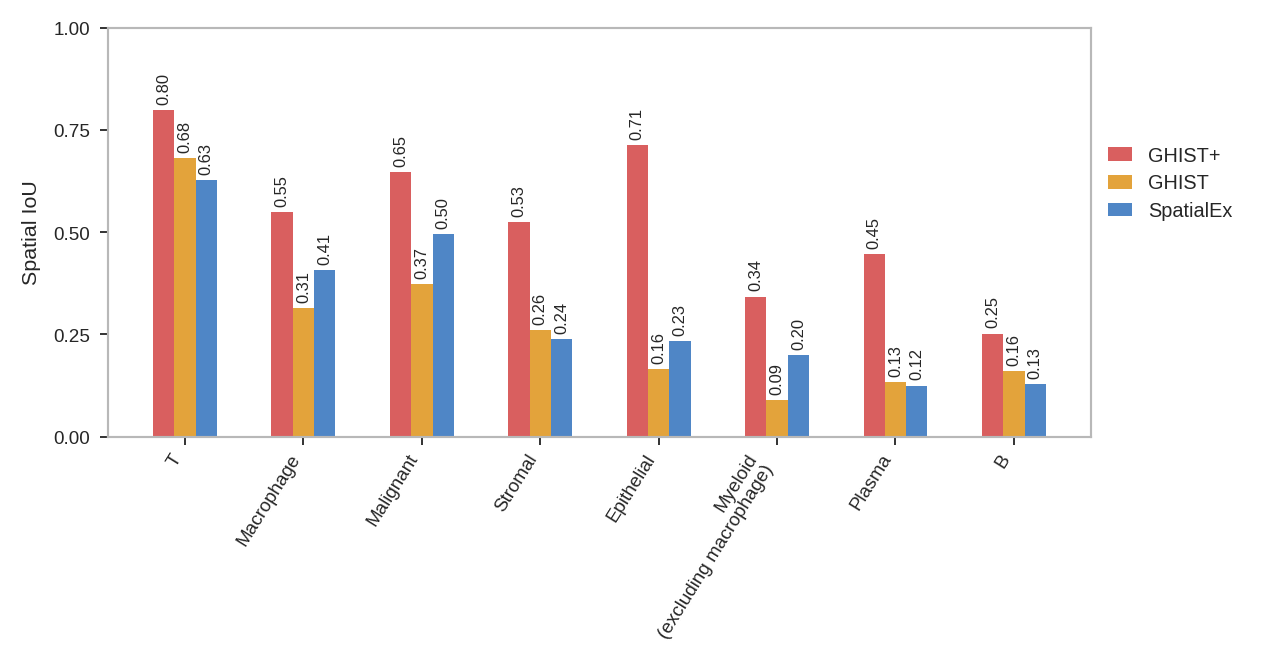

In [25]:
import json
import os
import warnings
from pathlib import Path

warnings.filterwarnings(
    "ignore",
    message=".*pkg_resources is deprecated as an API.*",
    category=UserWarning,
)
warnings.filterwarnings(
    "ignore",
    message=".*pkg_resources.*",
    category=UserWarning,
)
warnings.filterwarnings(
    "ignore",
    message=".*pkg_resources.*",
    category=DeprecationWarning,
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    import pyucell as uc
    import anndata as ad

REPO = Path(globals().get("REPO", Path.cwd()))
BUNDLE = Path(globals().get("BUNDLE", REPO.parent / "example_bundle"))
CONFIG = Path(globals().get("CONFIG", REPO / "configs" / "config_breast2_inference_example.json"))
OUTPUT_DIR = Path(globals().get("OUTPUT_DIR", BUNDLE / "inference_outputs" / "breast2_fullslide"))

ASSET_DIR = BUNDLE / "manuscript_assets" / "fig2_fig4_breast_checkpoint"
GROUND_TRUTH_DIR = ASSET_DIR / "ground_truth"

def latest_file(folder, pattern):
    hits = sorted(Path(folder).glob(pattern))
    return hits[-1] if hits else None

fp_ghist_plus = latest_file(OUTPUT_DIR, "*_pred_expr_scaled.csv")
fp_ghist = ASSET_DIR / "ghist" / "breast2_ghist_epoch30_pred_expr.csv"
fp_spatialex = ASSET_DIR / "spatialex" / "breast2_spatialex_pred_expr.csv"
fp_gt_celltype = GROUND_TRUTH_DIR / "cell_type_filtered.csv"
fp_coords = GROUND_TRUTH_DIR / "cell_coords.csv"
out_csv_fp = OUTPUT_DIR / "fig2_class_spatial_iou_plot_data.csv"

required = {
    "GHIST+ prediction": fp_ghist_plus,
    "GHIST prediction": fp_ghist,
    "SpatialEx prediction": fp_spatialex,
    "ground-truth cell types": fp_gt_celltype,
    "cell coordinates": fp_coords,
    "config": CONFIG,
}

missing = [name for name, path in required.items() if path is None or not Path(path).exists()]
if missing:
    raise FileNotFoundError("Missing required file(s): " + ", ".join(missing))

with open(CONFIG, "r", encoding="utf-8") as f:
    expr_scale = float(json.load(f)["data"]["expr_scale"])

SOURCE_COLORS = {
    "GHIST+": "#d95f5f",
    "GHIST": "#e3a33b",
    "SpatialEx": "#4f86c6",
}

CLASS_ORDER = [
    "T",
    "Macrophage",
    "Malignant",
    "Stromal",
    "Epithelial",
    "Myeloid (excluding macrophage)",
    "Plasma",
    "B",
]

CLASS_MARKERS = {
    "B": ["MS4A1", "CD79A", "CD79B", "BANK1"],
    "Epithelial": ["EPCAM", "CDH1", "ELF3", "KRT8", "KRT7", "KRT5", "KRT14", "KRT15"],
    "Macrophage": ["C1QA", "C1QC", "APOC1", "CD68", "CD163", "MRC1", "MMP12"],
    "Malignant": ["ERBB2", "MKI67", "TOP2A", "CCND1", "APOBEC3B", "LYPD3", "S100A14", "TACSTD2", "CLDN4"],
    "Myeloid (excluding macrophage)": ["FCER1A", "CD1C", "CLEC9A", "LILRA4", "IL3RA", "CD14", "S100A8", "MNDA", "ITGAX"],
    "Plasma": ["MZB1", "DERL3", "TNFRSF17", "PRDM1", "TENT5C"],
    "Stromal": ["LUM", "PDGFRA", "PDGFRB", "ACTA2", "MYH11", "DPT", "CCDC80", "POSTN", "LRRC15", "MMP2", "PCOLCE"],
    "T": ["CD3D", "CD3E", "CD3G", "TRAC", "CD247", "IL7R", "LTB"],
}

MIN_GENES_PER_CLASS = 2
BIN_SIZE = 150.0
SIGMA_BINS = 1.2

def pick_col(columns, candidates):
    for c in candidates:
        if c in columns:
            return c
    return None

def load_expr_matrix(path):
    preview = pd.read_csv(path, nrows=5)
    id_col = pick_col(preview.columns, ["c_id", "cell_id", "cellID", "id"])

    if id_col is not None:
        df = pd.read_csv(path)
        df[id_col] = df[id_col].astype(str).str.strip()
        df = df.set_index(id_col)
    else:
        df = pd.read_csv(path, index_col=0)
        df.index = df.index.astype(str).str.strip()

    df.index = df.index.astype(str).str.strip()
    df.columns = df.columns.astype(str).str.strip()
    df = df.loc[~df.index.duplicated()].copy()
    df = df.loc[:, ~df.columns.duplicated()].copy()
    df = df.drop(columns=[c for c in ["x", "y", "x_coord", "y_coord"] if c in df.columns], errors="ignore")
    df = df.apply(pd.to_numeric, errors="coerce")
    return df

def load_labels(path):
    df = pd.read_csv(path, dtype=str)
    id_col = pick_col(df.columns, ["c_id", "cell_id", "cellID", "id"])
    ct_col = pick_col(df.columns, ["ct", "cell_type", "celltype", "label"])

    if id_col is None or ct_col is None:
        raise ValueError("Cell-type file must contain a cell ID column and a cell-type column.")

    df = df.rename(columns={id_col: "c_id", ct_col: "ct"})[["c_id", "ct"]].copy()
    df["c_id"] = df["c_id"].astype(str).str.strip()
    df["ct"] = df["ct"].astype(str).str.strip()

    return (
        df.dropna(subset=["c_id", "ct"])
        .drop_duplicates("c_id")
        .set_index("c_id")["ct"]
    )

def load_coords(path):
    df = pd.read_csv(path, dtype=str)
    id_col = pick_col(df.columns, ["c_id", "cell_id", "cellID", "id"])
    x_col = pick_col(df.columns, ["x_coord", "x", "x_um", "x0"])
    y_col = pick_col(df.columns, ["y_coord", "y", "y_um", "y0"])

    if id_col is None or x_col is None or y_col is None:
        raise ValueError("Coordinate file must contain cell ID, x, and y columns.")

    df = df.rename(columns={id_col: "c_id", x_col: "x_coord", y_col: "y_coord"})[
        ["c_id", "x_coord", "y_coord"]
    ].copy()

    df["c_id"] = df["c_id"].astype(str).str.strip()
    df["x_coord"] = pd.to_numeric(df["x_coord"], errors="coerce")
    df["y_coord"] = pd.to_numeric(df["y_coord"], errors="coerce")

    return (
        df.dropna(subset=["c_id", "x_coord", "y_coord"])
        .drop_duplicates("c_id")
        .set_index("c_id")
    )

def build_density_map(coords_df, mask_s, xbins, ybins, sigma_bins):
    pts = coords_df.loc[mask_s.index[mask_s], ["y_coord", "x_coord"]]

    hist, _, _ = np.histogram2d(
        pts["y_coord"],
        pts["x_coord"],
        bins=[ybins, xbins],
    )

    hist = hist.astype(float)

    if sigma_bins > 0:
        hist = gaussian_filter(hist, sigma=sigma_bins)

    if hist.sum() > 0:
        hist = hist / hist.sum()

    return hist

def spatial_iou(a, b):
    inter = np.minimum(a, b).sum()
    union = np.maximum(a, b).sum()
    return inter / union if union > 0 else np.nan

gt_labels = load_labels(fp_gt_celltype)
coords = load_coords(fp_coords)

expr_sources = {
    "GHIST+": load_expr_matrix(fp_ghist_plus),
    "GHIST": load_expr_matrix(fp_ghist),
    "SpatialEx": expr_scale * np.log1p(load_expr_matrix(fp_spatialex).clip(lower=0)),
}

source_order = ["GHIST+", "GHIST", "SpatialEx"]

common_ids = set(gt_labels.index) & set(coords.index)
for src in source_order:
    common_ids &= set(expr_sources[src].index)
common_ids = sorted(common_ids)

gt_labels = gt_labels.loc[common_ids]
coords = coords.loc[common_ids]
for src in source_order:
    expr_sources[src] = expr_sources[src].loc[common_ids]

common_genes = set(expr_sources[source_order[0]].columns)
for src in source_order[1:]:
    common_genes &= set(expr_sources[src].columns)
common_genes = sorted(common_genes)

for src in source_order:
    expr_sources[src] = expr_sources[src].loc[:, common_genes]

ucell_max_rank = min(1500, len(common_genes))

usable_bio_classes = []
for cls in CLASS_ORDER:
    used_genes = [g for g in CLASS_MARKERS[cls] if g in common_genes]
    n_pos = int((gt_labels == cls).sum())
    if len(used_genes) >= MIN_GENES_PER_CLASS and n_pos > 0:
        usable_bio_classes.append(cls)

class_score_sources = {}

for src in source_order:
    expr_df = expr_sources[src]

    adata = ad.AnnData(
        X=expr_df.to_numpy(dtype=np.float32),
        obs=pd.DataFrame(index=expr_df.index.astype(str)),
        var=pd.DataFrame(index=expr_df.columns.astype(str)),
    )

    adata.obs_names_make_unique()
    adata.var_names_make_unique()

    signatures = {
        cls: CLASS_MARKERS[cls]
        for cls in usable_bio_classes
    }

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        uc.compute_ucell_scores(
            adata,
            signatures=signatures,
            max_rank=ucell_max_rank,
            missing_genes="skip",
            chunk_size=500,
            suffix="_UCell",
            n_jobs=1,
        )

    score_df = pd.DataFrame(index=expr_df.index)

    for cls in usable_bio_classes:
        score_df[cls] = adata.obs[f"{cls}_UCell"].to_numpy()

    class_score_sources[src] = score_df

xmin, xmax = coords["x_coord"].min(), coords["x_coord"].max()
ymin, ymax = coords["y_coord"].min(), coords["y_coord"].max()

xbins = np.arange(xmin, xmax + BIN_SIZE, BIN_SIZE)
ybins = np.arange(ymin, ymax + BIN_SIZE, BIN_SIZE)

rows = []

for cls in usable_bio_classes:
    gt_mask = gt_labels == cls
    n_pos = int(gt_mask.sum())

    if n_pos == 0:
        continue

    gt_map = build_density_map(coords, gt_mask, xbins, ybins, SIGMA_BINS)

    for src in source_order:
        score = class_score_sources[src][cls]
        top_ids = score.nlargest(n_pos).index

        pred_mask = pd.Series(False, index=score.index)
        pred_mask.loc[top_ids] = True

        pred_map = build_density_map(coords, pred_mask, xbins, ybins, SIGMA_BINS)

        rows.append({
            "Cell type": cls,
            "Model": src,
            "Spatial IoU": spatial_iou(gt_map, pred_map),
        })

plot_data = pd.DataFrame(rows)
spatial_iou_df = (
    plot_data
    .pivot(index="Cell type", columns="Model", values="Spatial IoU")
    .loc[usable_bio_classes, source_order]
)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
plot_data.to_csv(out_csv_fp, index=False)

display_names = {
    "Myeloid (excluding macrophage)": "Myeloid\n(excluding macrophage)",
}

x_labels = [display_names.get(cls, cls) for cls in usable_bio_classes]

fig, ax = plt.subplots(figsize=(6.2, 3.0), dpi=220, facecolor="white")

x = np.arange(len(usable_bio_classes))
width = 0.18
offsets = np.linspace(-width, width, len(source_order))

for off, src in zip(offsets, source_order):
    vals = spatial_iou_df[src].to_numpy(dtype=float)

    bars = ax.bar(
        x + off,
        vals,
        width=width,
        color=SOURCE_COLORS[src],
        edgecolor="none",
        linewidth=0,
        label=src,
    )

    for bar, val in zip(bars, vals):
        if np.isfinite(val):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                val + 0.015,
                f"{val:.2f}",
                ha="center",
                va="bottom",
                fontsize=5.4,
                rotation=90,
            )

ax.set_xticks(x)
ax.set_xticklabels(x_labels, rotation=58, ha="right", fontsize=6.2)
ax.set_ylabel("Spatial IoU", fontsize=7)
ax.set_ylim(0, max(1.0, float(spatial_iou_df.max().max()) + 0.12))
ax.set_yticks([0.00, 0.25, 0.50, 0.75, 1.00])
ax.tick_params(axis="y", labelsize=6.2, width=0.6, length=2.5)
ax.tick_params(axis="x", width=0.6, length=2.5, pad=2)
ax.grid(False)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("#b8b8b8")
    spine.set_linewidth(0.7)

ax.legend(
    frameon=False,
    loc="center left",
    bbox_to_anchor=(1.01, 0.62),
    fontsize=6.5,
    handlelength=1.2,
    labelspacing=0.45,
    borderaxespad=0.0,
)

fig.subplots_adjust(left=0.10, right=0.82, bottom=0.34, top=0.96)
plt.show()

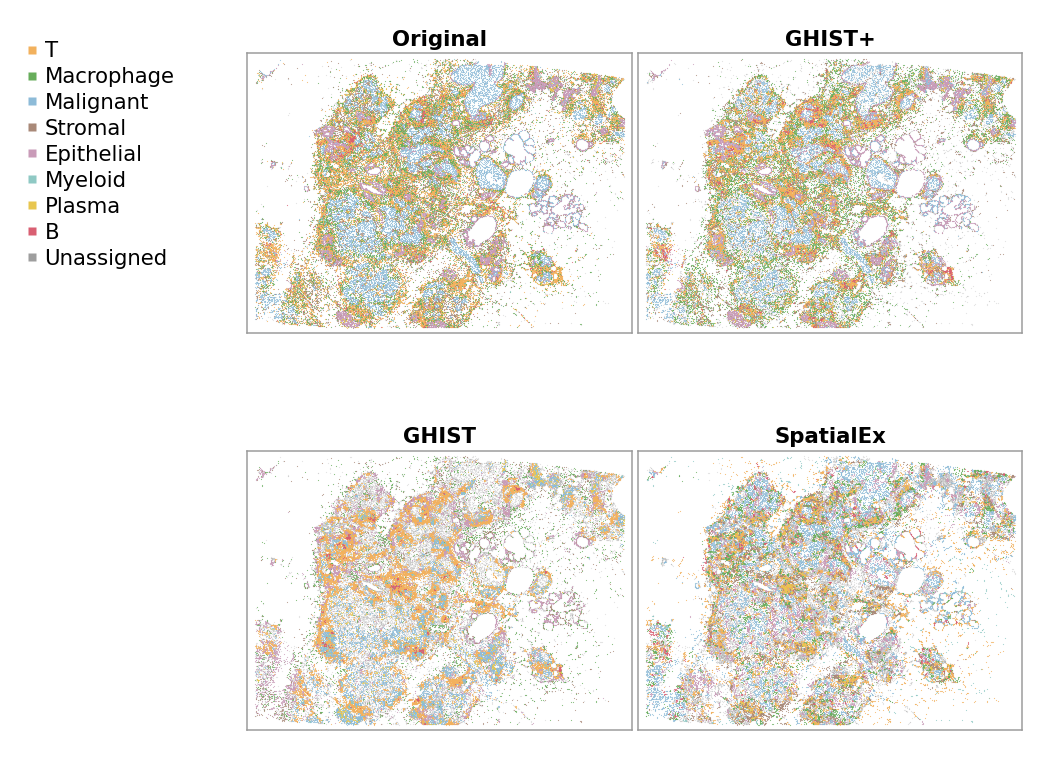

In [2]:
from pathlib import Path
import warnings

warnings.filterwarnings(
    "ignore",
    message=".*pkg_resources is deprecated as an API.*",
    category=UserWarning,
)
warnings.filterwarnings(
    "ignore",
    message=".*pkg_resources.*",
    category=UserWarning,
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    import anndata as ad
    import pyucell as uc


# -------------------- paths --------------------
REPO = Path(globals().get("REPO", Path.cwd()))
BUNDLE = Path(globals().get("BUNDLE", REPO.parent / "example_bundle"))
OUTPUT_DIR = Path(globals().get("OUTPUT_DIR", BUNDLE / "inference_outputs" / "breast2_fullslide"))

ASSET_DIR = BUNDLE / "manuscript_assets" / "fig2_fig4_breast_checkpoint"
GROUND_TRUTH_DIR = ASSET_DIR / "ground_truth"


def latest_file(folder, pattern):
    hits = sorted(Path(folder).glob(pattern))
    return hits[-1] if hits else None


fp_ghist_plus = latest_file(OUTPUT_DIR, "*_pred_expr_scaled.csv")
fp_ghist = ASSET_DIR / "ghist" / "breast2_ghist_epoch30_pred_expr.csv"
fp_spatialex = ASSET_DIR / "spatialex" / "breast2_spatialex_pred_expr.csv"
fp_gt_celltype = GROUND_TRUTH_DIR / "cell_type_filtered.csv"
fp_coords = GROUND_TRUTH_DIR / "cell_coords.csv"

required = {
    "GHIST+ expression prediction": fp_ghist_plus,
    "GHIST expression prediction": fp_ghist,
    "SpatialEx expression prediction": fp_spatialex,
    "ground-truth cell types": fp_gt_celltype,
    "cell coordinates": fp_coords,
}

missing = [name for name, path in required.items() if path is None or not Path(path).exists()]
if missing:
    raise FileNotFoundError(
        "Missing required input(s): "
        + ", ".join(missing)
        + ". Add these files to the example bundle before running this cell."
    )


# -------------------- markers --------------------
PANEL_ORDER = ["Original", "GHIST+", "GHIST", "SpatialEx"]

CLASS_ORDER = [
    "T",
    "Macrophage",
    "Malignant",
    "Stromal",
    "Epithelial",
    "Myeloid",
    "Plasma",
    "B",
    "Unassigned",
]

CLASS_MARKERS = {
    "B": ["MS4A1", "CD79A", "CD79B", "BANK1"],
    "Epithelial": ["KRT5", "KRT14", "KRT15", "EPCAM"],
    "Macrophage": ["LYZ", "C1QA", "C1QC", "CD68", "FCER1G"],
    "Malignant": ["EPCAM", "KRT8", "ERBB2", "MKI67"],
    "Myeloid": ["FCER1A", "ITGAX", "LILRA4"],
    "Plasma": ["MZB1", "DERL3", "TNFRSF17"],
    "Stromal": ["ACTA2", "VWF", "PECAM1"],
    "T": ["CD3D", "CD3E", "TRAC", "IL7R", "LTB", "NKG7"],
}

CLASS_COLORS = {
    "T": "#f2b15d",
    "Macrophage": "#67ad5b",
    "Malignant": "#8dbbd8",
    "Stromal": "#a98978",
    "Epithelial": "#c99bb8",
    "Myeloid": "#8fc9c4",
    "Plasma": "#e8c64f",
    "B": "#d95f72",
    "Unassigned": "#9e9e9e",
}

MIN_GENES_PER_CLASS = 2
POINT_SIZE = 0.22
POINT_ALPHA = 0.78
UNASSIGNED_ALPHA = 0.28


# -------------------- helpers --------------------
def pick_col(columns, candidates):
    clean = {str(c).strip(): c for c in columns}
    for c in candidates:
        if c in clean:
            return clean[c]
    return None


def normalize_ct(x):
    x = str(x).strip()
    mapping = {
        "B Cells": "B",
        "B": "B",
        "CD4 T": "T",
        "CD8 T": "T",
        "T": "T",
        "Plasma": "Plasma",
        "Macrophage": "Macrophage",
        "CD163+ Macrophage": "Macrophage",
        "IRF7+ DC": "Myeloid",
        "LAMP3+ DC": "Myeloid",
        "Mast cells": "Myeloid",
        "Myeloid": "Myeloid",
        "Myeloid (excluding macrophage)": "Myeloid",
        "Firoblast": "Stromal",
        "Fibroblast": "Stromal",
        "Stromal": "Stromal",
        "STAB2+ Endothelial": "Stromal",
        "VWF+ Endothelial": "Stromal",
        "Endothelial": "Stromal",
        "Malignant": "Malignant",
        "Epithelial": "Epithelial",
        "Unassigned": "Unassigned",
    }
    return mapping.get(x, x)


def sort_cell_ids(ids):
    def key(x):
        try:
            return (0, int(x))
        except ValueError:
            return (1, str(x))
    return sorted(ids, key=key)


def load_expr_matrix(path):
    preview = pd.read_csv(path, nrows=5)
    id_col = pick_col(preview.columns, ["c_id", "cell_id", "cellID", "id", "Cell ID"])

    if id_col is not None:
        df = pd.read_csv(path)
        df[id_col] = df[id_col].astype(str).str.strip()
        df = df.set_index(id_col)
    else:
        df = pd.read_csv(path, index_col=0)
        df.index = df.index.astype(str).str.strip()

    df.index = df.index.astype(str).str.strip()
    df.columns = df.columns.astype(str).str.strip()
    df = df.loc[~df.index.duplicated()].copy()
    df = df.loc[:, ~df.columns.duplicated()].copy()
    df = df.drop(columns=[c for c in ["x", "y", "x_coord", "y_coord"] if c in df.columns], errors="ignore")
    df = df.apply(pd.to_numeric, errors="coerce")
    return df


def load_labels(path):
    df = pd.read_csv(path, dtype=str)
    id_col = pick_col(df.columns, ["c_id", "cell_id", "cellID", "id", "Cell ID"])
    ct_col = pick_col(df.columns, ["ct", "cell_type", "celltype", "label", "Cell type label"])

    if id_col is None or ct_col is None:
        raise ValueError("Could not find cell ID and cell-type columns in the ground-truth file.")

    df = df.rename(columns={id_col: "c_id", ct_col: "ct"})[["c_id", "ct"]].copy()
    df["c_id"] = df["c_id"].astype(str).str.strip()
    df["ct"] = df["ct"].map(normalize_ct)

    return (
        df.dropna(subset=["c_id", "ct"])
        .drop_duplicates("c_id")
        .set_index("c_id")["ct"]
    )


def load_coords(path):
    df = pd.read_csv(path)
    id_col = pick_col(df.columns, ["c_id", "cell_id", "cellID", "id", "Cell ID"])
    x_col = pick_col(df.columns, ["x_coord", "x", "x_um", "x0", "x coordinate"])
    y_col = pick_col(df.columns, ["y_coord", "y", "y_um", "y0", "y coordinate"])

    if id_col is None or x_col is None or y_col is None:
        raise ValueError("Could not find cell ID, x, and y columns in the coordinate file.")

    df = df.rename(columns={id_col: "c_id", x_col: "x_coord", y_col: "y_coord"})
    df["c_id"] = df["c_id"].astype(str).str.strip()
    df["x_coord"] = pd.to_numeric(df["x_coord"], errors="coerce")
    df["y_coord"] = pd.to_numeric(df["y_coord"], errors="coerce")

    return (
        df.dropna(subset=["c_id", "x_coord", "y_coord"])
        .drop_duplicates("c_id")
        .set_index("c_id")[["x_coord", "y_coord"]]
    )


def quota_matched_cell_type_labels(score_df, gt_labels, class_order):
    pct_df = score_df[class_order].rank(axis=0, method="average", pct=True)
    quotas = gt_labels.value_counts().reindex(class_order, fill_value=0).to_dict()

    candidate_blocks = []
    for cls in class_order:
        k = int(quotas[cls])
        if k <= 0:
            continue

        top_ids = score_df[cls].nlargest(k).index
        candidate_blocks.append(
            pd.DataFrame({
                "c_id": top_ids,
                "Class": cls,
                "pct": pct_df.loc[top_ids, cls].to_numpy(),
                "raw": score_df.loc[top_ids, cls].to_numpy(),
            })
        )

    assigned = pd.Series("Unassigned", index=score_df.index, dtype=object)
    if not candidate_blocks:
        return assigned

    candidates = pd.concat(candidate_blocks, ignore_index=True)
    candidates = candidates.sort_values(["pct", "raw"], ascending=[False, False])

    used_cells = set()
    class_counts = {cls: 0 for cls in class_order}

    for row in candidates.itertuples(index=False):
        if row.c_id in used_cells:
            continue
        if class_counts[row.Class] >= quotas[row.Class]:
            continue

        assigned.loc[row.c_id] = row.Class
        used_cells.add(row.c_id)
        class_counts[row.Class] += 1

    return assigned


# -------------------- load data --------------------
gt_labels = load_labels(fp_gt_celltype)
coords = load_coords(fp_coords)

expr_sources = {
    "GHIST+": load_expr_matrix(fp_ghist_plus),
    "GHIST": load_expr_matrix(fp_ghist),
    "SpatialEx": load_expr_matrix(fp_spatialex),
}

source_order = ["GHIST+", "GHIST", "SpatialEx"]

common_ids = set(gt_labels.index) & set(coords.index)
for src in source_order:
    common_ids &= set(expr_sources[src].index)

common_ids = sort_cell_ids(common_ids)

gt_labels = gt_labels.loc[common_ids]
coords = coords.loc[common_ids]

for src in source_order:
    expr_sources[src] = expr_sources[src].loc[common_ids]

common_genes = set(expr_sources[source_order[0]].columns)
for src in source_order[1:]:
    common_genes &= set(expr_sources[src].columns)

common_genes = sorted(common_genes)

for src in source_order:
    expr_sources[src] = expr_sources[src].loc[:, common_genes]


# -------------------- marker scoring --------------------
usable_bio_classes = []

for cls in CLASS_ORDER:
    if cls == "Unassigned":
        continue

    used_genes = [g for g in CLASS_MARKERS[cls] if g in common_genes]
    if len(used_genes) < MIN_GENES_PER_CLASS:
        raise RuntimeError(
            f"{cls} has only {len(used_genes)} marker genes available: {used_genes}"
        )

    usable_bio_classes.append(cls)

max_rank = min(1500, len(common_genes))

score_sources = {}

for src in source_order:
    expr_df = expr_sources[src]

    adata = ad.AnnData(
        X=expr_df.to_numpy(dtype=np.float32),
        obs=pd.DataFrame(index=expr_df.index.astype(str)),
        var=pd.DataFrame(index=expr_df.columns.astype(str)),
    )
    adata.obs_names_make_unique()
    adata.var_names_make_unique()

    signatures = {
        cls: [g for g in CLASS_MARKERS[cls] if g in common_genes]
        for cls in usable_bio_classes
    }

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        uc.compute_ucell_scores(
            adata,
            signatures=signatures,
            max_rank=max_rank,
            missing_genes="skip",
            chunk_size=500,
            suffix="_UCell",
            n_jobs=1,
        )

    score_df = pd.DataFrame(index=expr_df.index)

    for cls in usable_bio_classes:
        score_df[cls] = adata.obs[f"{cls}_UCell"].to_numpy(dtype=float)

    score_df["Unassigned"] = (1.0 - score_df[usable_bio_classes].max(axis=1)).clip(0.0, 1.0)
    score_sources[src] = score_df[CLASS_ORDER]


# -------------------- derive labels --------------------
plot_df = coords.copy()
plot_df["Original"] = gt_labels

for src in source_order:
    pred = quota_matched_cell_type_labels(
        score_df=score_sources[src],
        gt_labels=gt_labels,
        class_order=CLASS_ORDER,
    )
    plot_df[src] = pred.reindex(common_ids)


# -------------------- plot --------------------
x_pad = 0.02 * (plot_df["x_coord"].max() - plot_df["x_coord"].min())
y_pad = 0.02 * (plot_df["y_coord"].max() - plot_df["y_coord"].min())

xlim = (plot_df["x_coord"].min() - x_pad, plot_df["x_coord"].max() + x_pad)
ylim = (plot_df["y_coord"].min() - y_pad, plot_df["y_coord"].max() + y_pad)

fig = plt.figure(figsize=(7.2, 5.4), dpi=180, facecolor="white")
gs = fig.add_gridspec(
    2,
    3,
    width_ratios=[0.58, 1.0, 1.0],
    wspace=0.02,
    hspace=0.13,
)

legend_ax = fig.add_subplot(gs[:, 0])
legend_ax.axis("off")

axes = [
    fig.add_subplot(gs[0, 1]),
    fig.add_subplot(gs[0, 2]),
    fig.add_subplot(gs[1, 1]),
    fig.add_subplot(gs[1, 2]),
]

draw_order = ["Unassigned"] + [ct for ct in CLASS_ORDER if ct != "Unassigned"]

for ax, panel in zip(axes, PANEL_ORDER):
    labels = plot_df[panel]

    for ct in draw_order:
        mask = labels == ct
        if mask.sum() == 0:
            continue

        ax.scatter(
            plot_df.loc[mask, "x_coord"],
            plot_df.loc[mask, "y_coord"],
            s=POINT_SIZE,
            c=CLASS_COLORS[ct],
            alpha=UNASSIGNED_ALPHA if ct == "Unassigned" else POINT_ALPHA,
            linewidths=0,
            rasterized=True,
        )

    ax.set_title(panel, fontsize=8.5, fontweight="bold", pad=3)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(False)

    for side in ["left", "right", "top", "bottom"]:
        ax.spines[side].set_visible(True)
        ax.spines[side].set_color("#9a9a9a")
        ax.spines[side].set_linewidth(0.6)

legend_handles = [
    Line2D(
        [0],
        [0],
        marker="s",
        linestyle="none",
        markerfacecolor=CLASS_COLORS[ct],
        markeredgecolor="none",
        markersize=3.2,
        label=ct,
    )
    for ct in CLASS_ORDER
]

legend_ax.legend(
    handles=legend_handles,
    labels=CLASS_ORDER,
    frameon=False,
    loc="upper left",
    bbox_to_anchor=(0.0, 0.98),
    handlelength=0.5,
    handletextpad=0.35,
    borderaxespad=0.0,
    labelspacing=0.28,
    fontsize=8.5,
)

plt.show()